# Clustering and K-means

In this notebook we will be going through my own K-means implementation and that vs the SKLEARN k-means will also be visualizing and using the statistics for it. Will also be using my own PCA for it

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())

# MiniLearn
from minilearn.helper import ezcols
from minilearn.kMeans import KMeans
from minilearn.preprocessing.Scaler import StandardScalerMM
from minilearn.preprocessing.PCA import PCA

# sklearn for comparison and t-SNE
from sklearn.cluster import KMeans as SkKMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


Import as always and split up the features

In [2]:
features = pd.read_csv("data/processed/features.csv")
feature_cols = ezcols()

X = features[feature_cols].values
y = features["emotion"].values

print("X:", X.shape)
print("y:", y.shape)

X: (2451, 480)
y: (2451,)


Down below I am making the K-means vs the Sklearn means. Both are split up into 8 different clusters and goes through 300 iterations. However, Sklearn has n_init which I did not make to my method which is rather simple. As you can see the results are pretty different between both. The difference between the results is that I choose 8 random starting indexes, however Sklearn uses 10 different pass throughs to find the best starting seed. Also when sk-learn chooses its first seed the subsequent ones are biased to make sure they are away from the first point

In [ ]:
scaler = StandardScalerMM()
scaler.fit(X)
X_scaled = scaler.transform(X)

# MiniLearn KMeans
km_mm = KMeans(n_clusters=8, max_iters=300, random_state=20)
labels_mm = km_mm.fit_predict(X_scaled)

# sklearn KMeans
km_sk = SkKMeans(n_clusters=8, max_iter=300, random_state=20, n_init=10)
labels_sk = km_sk.fit_predict(X_scaled)

print("MiniLearn cluster counts:", pd.Series(labels_mm).value_counts().sort_index().tolist())
print("sklearn cluster counts:  ", pd.Series(labels_sk).value_counts().sort_index().tolist())

MiniLearn cluster counts: [324, 424, 279, 526, 283, 240, 122, 253]
sklearn cluster counts:   [332, 512, 494, 324, 160, 343, 285, 1]


As explain above it makes sense that both the ARI and NMI are higher for SK-learn because of the things I just mentioned above. from what I read online the ARI and the NMI make sense for the handcrafted audio features we put into this. The data is also clumped well even though there is a lot of dimensionality

In [6]:
ari_mm = adjusted_rand_score(y, labels_mm)
nmi_mm = normalized_mutual_info_score(y, labels_mm)
ari_sk = adjusted_rand_score(y, labels_sk)
nmi_sk = normalized_mutual_info_score(y, labels_sk)

comp = pd.DataFrame({
    'Implementation': ['MiniLearn KMeans', 'sklearn KMeans'],
    'ARI': [round(ari_mm, 4), round(ari_sk, 4)],
    'NMI': [round(nmi_mm, 4), round(nmi_sk, 4)],
})
comp

,Implementation,ARI,NMI
0,MiniLearn KMeans,0.0500,0.1265
1,sklearn KMeans,0.0578,0.1328


Its interesting to look at the different emotions it gets per cluster. To me and I think to any observer aswell the data looks as if it was random. What we would want to see is for each emotion to be strongly set into one cluster and the other emotions be 0 in the table. The only very good clustering seems to be angry in 4 and 5. 

In [7]:
# Cross-tab: rows = true emotion, cols = cluster
ct = pd.crosstab(pd.Series(y, name='emotion'), pd.Series(labels_mm, name='cluster'))
print("MiniLearn -- rows=emotion, cols=cluster:")
ct

MiniLearn -- rows=emotion, cols=cluster:


cluster,0,1,2,3,4,5,6,7
emotion,,,,,,,,
angry,9,32,12,51,120,93,1,58
calm,91,58,84,65,11,0,59,8
disgust,0,42,0,98,18,5,14,14
fearful,38,53,34,66,57,60,14,54
happy,57,62,41,48,55,61,1,51
neutral,41,45,42,41,7,0,7,5
sad,88,65,66,60,12,10,24,51
surprised,0,67,0,97,3,11,2,12


This is just a rexaminiation of the table avoe in a hratmap style

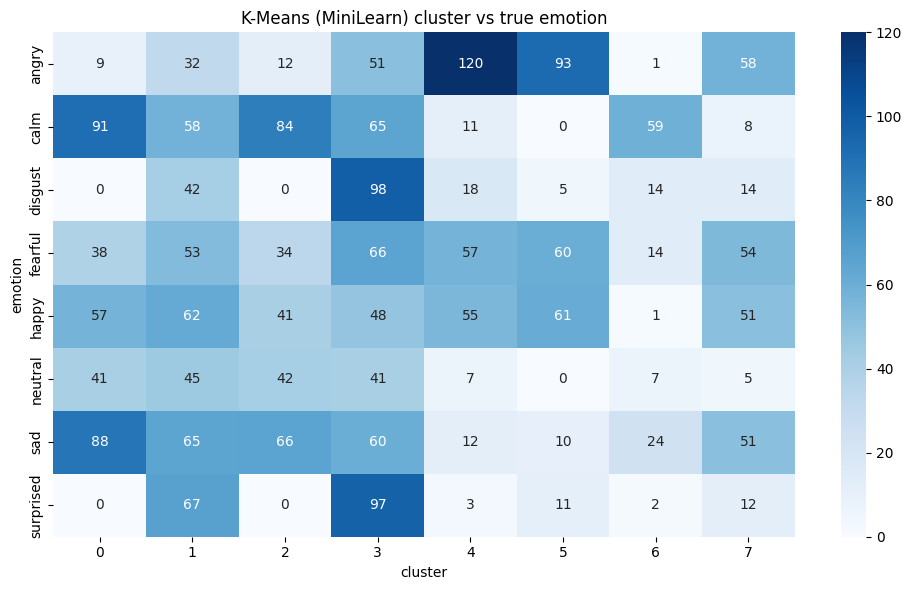

In [8]:
# Heatmap version
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title("K-Means (MiniLearn) cluster vs true emotion")
plt.tight_layout()
plt.show()

Looking at these two side by side basically shows me that K-Means did find something, just not what I wanted it to find. On the left you can see the clusters actually have their own spaces in the plot, like orange (C1) is mostly on the right, blue (C0) is up top, green (C2) is upper left. So the algorithm wasnt just randomly throwing points around, it found real structure.
But then the right side is the exact same points just colored by the actual emotion, and its kind of a mess. All 8 colors are mixed together everywhere, theres no angry corner or calm corner or anything like that. And since both plots are literally the same projection, what that tells me is that PC1 (the axis the clusters are spreading across) isnt really about emotion at all.
My guess is PC1 is picking up on something like loudness or energy or how bright the sound is, which makes sense because thats what most of my features end up measuring. The emotion stuff is probably on smaller components that K-Means just doesnt care about since its only looking at euclidean distance and goes after the biggest variance. Which lines up with the low ARI and NMI numbers I got, the loudest signal in my features just isnt the emotion.

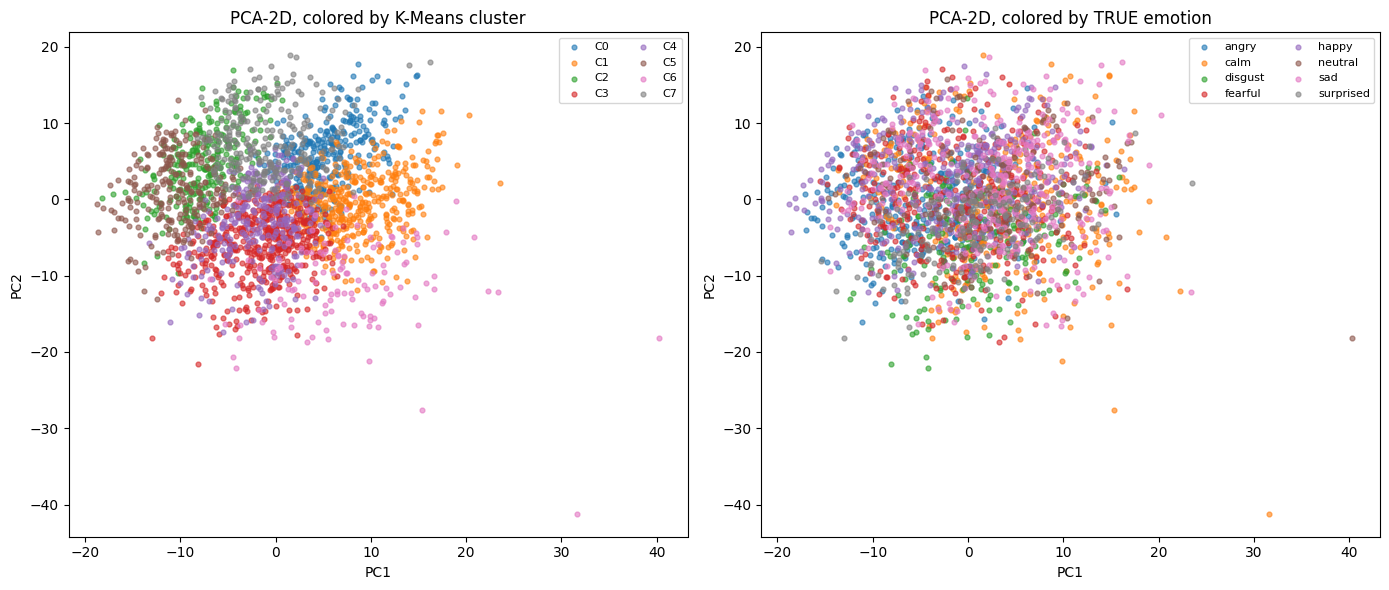

In [9]:
# PCA to 2D using MiniLearn
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colored by MiniLearn cluster
for c in np.unique(labels_mm):
    mask = labels_mm == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=12, alpha=0.6, label=f'C{c}')
axes[0].set_title("PCA-2D, colored by K-Means cluster")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=8, ncol=2)

# Colored by true emotion
for e in np.unique(y):
    mask = y == e
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=12, alpha=0.6, label=e)
axes[1].set_title("PCA-2D, colored by TRUE emotion")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

So coloring the same t-SNE by gender basically tells me exactly why the clustering didnt work. The males and females split almost perfectly down the middle, females on the left and males on the right with barely any overlap. Thats the kind of clean separation I was hoping to see when I colored by emotion and just didnt get.
What I think this is telling me is that the biggest thing my features are picking up on isnt emotion at all, its just whos talking. Male and female voices are pretty different acoustically, like males are usually around 100hz and females are double that around 200hz, and a lot of my features (especially MFCCs and the spectral stuff) are basically measuring the shape of the vocal tract. So gender is kind of baked into the features before emotion even gets a chance to show up.
And K-Means just goes after whatever the biggest source of variance is because its using euclidean distance, so it locks onto gender and never really gets to emotion. Which explains why my ARI and NMI were so low, theres just a bigger signal in the way.

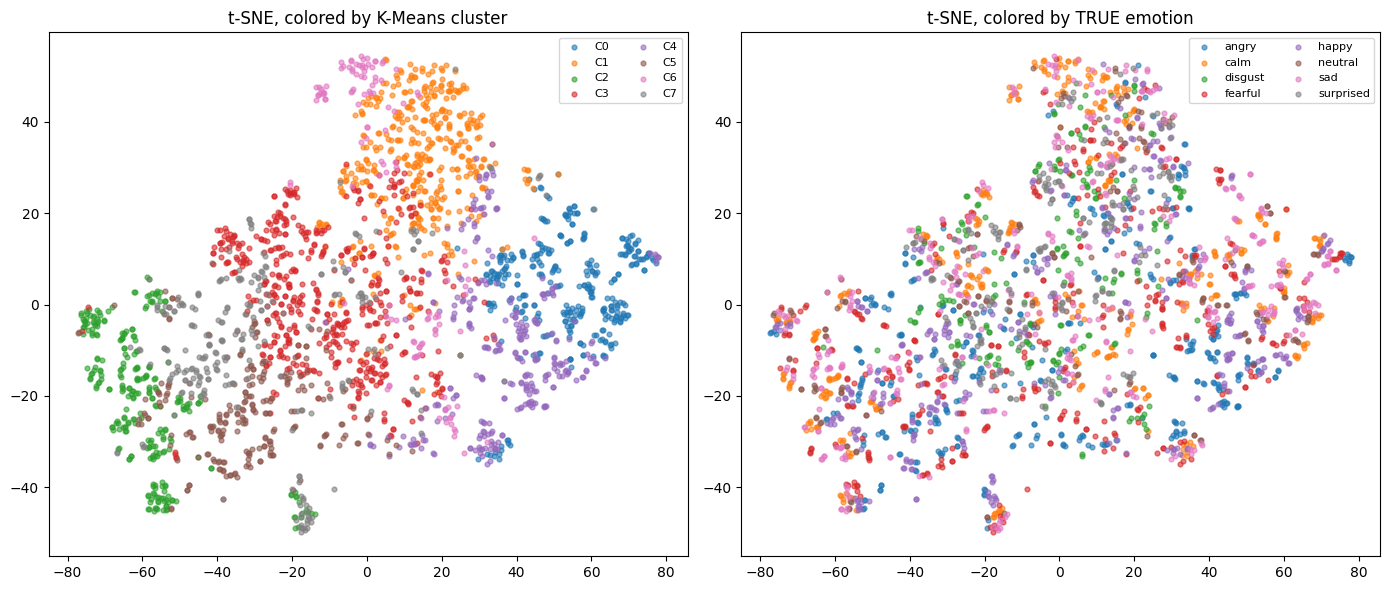

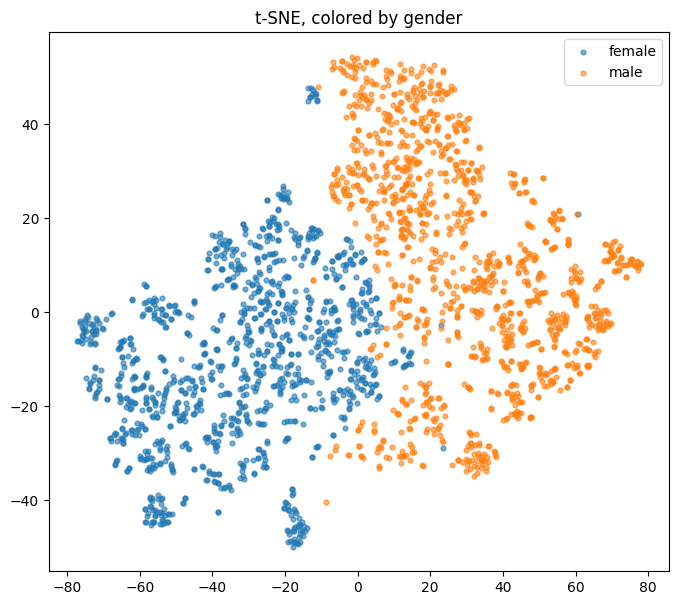

In [ ]:
# t-SNE is non-linear so it usually shows separations PCA can't.
tsne = TSNE(n_components=2, perplexity=30, random_state=20, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for c in np.unique(labels_mm):
    mask = labels_mm == c
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=12, alpha=0.6, label=f'C{c}')
axes[0].set_title("t-SNE, colored by K-Means cluster")
axes[0].legend(fontsize=8, ncol=2)

for e in np.unique(y):
    mask = y == e
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=12, alpha=0.6, label=e)
axes[1].set_title("t-SNE, colored by TRUE emotion")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Map actor -> gender (odd=male, even=female per RAVDESS spec)
gender = features['gender']

fig, ax = plt.subplots(figsize=(8, 7))
for g in np.unique(gender):
    mask = gender == g
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=12, alpha=0.6, label=g)
ax.set_title("t-SNE, colored by gender")
ax.legend()
plt.show()